---

# Greatest GOAT of All Time?

*A recent post claims that the "most statistically dominant athlete" of all time was cricketer Don Bradman. It's a bold claim -- let's see if it holds up.*

In [*Chapter 4 of Probably Overthinking It*](https://allendowney.github.io/ProbablyOverthinkingIt/lognormal.html#the-greatest-of-all-time), I listed a few examples of athletes who are considered the Greatest Of All Time (GOAT), and noted that in many cases they are not just a little better than the second-best, but much better. That is, they are outliers among outliers.

And I suggested that part of the explanation for this phenomenon is that the distribution of accomplishment in many fields (at least, the ones where accomplishment can be quantified) follows a lognormal distribution.
That matters because the lognormal distribution has a long tail, which means that extreme values can be much farther from the mean than we would see in a Gaussian (normal) distribution.

So I was intrigued by [this post](https://www.instagram.com/reel/DZ6anr1CjT2/) about [Don Bradman](https://en.wikipedia.org/wiki/Don_Bradman#Statistical_summary):

> The most statistically dominant athlete ever isn’t Jordan or Messi — and you’ve probably never heard of him. 🏏
>
>I plotted the career batting averages of the greatest Test cricketers of all time. They make a clean bell curve. In cricket, averaging 50 makes you an immortal legend, and the all-time record holders top out around 60 — about 2 standard deviations above the mean.
>
>Then there’s Don Bradman: 99.94. More than 6 standard deviations out. The gap between him and the SECOND best player is bigger than the gap between #2 and the entire average. By the math, a batsman this good should appear about once in 7 billion.
>
> To be this far ahead in basketball, Michael Jordan would’ve had to average 43 points in every single game he ever played. No one in any sport — not Jordan, not Gretzky, not Messi — is this far from their peers.
>
> Not just the greatest. The single biggest outlier in the history of sport.

Let's see if that's true.
In particular, I'll investigate the "clean bell curve" -- it implies a Gaussian model of the data, which is where that "once in 7 billion" comes from.

To give away the ending, here's what I found:

* The data don't fit a Gaussian particularly well, especially in the tail, so the "one in 7 billion" might not be right.

* I thought they might fit a lognormal better, but I was wrong.

* It turns out that the data fit a Weibull distribution *very* well, and from that we can get a revised estimate of how much of a GOAT Bradman was.

As it turns out, he was a pretty goaty GOAT -- but not quite one in 7 billion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, weibull_min

from empiricaldist import (
    Cdf,
    TailDist,
    average_error,
    fit_normal,
    fit_scipy_dist,
    plot_fit_with_area,
    plot_model_bounds,
)


def decorate(**options):
    """Decorate the current axes."""
    legend = options.pop("legend", True)
    loc = options.pop("loc", "best")
    ax = plt.gca()
    ax.set(**options)

    handles, labels = ax.get_legend_handles_labels()
    if handles and legend:
        ax.legend(handles, labels, loc=loc)

    plt.tight_layout()

## Load the data

I got the data from [Kaggle](https://www.kaggle.com/datasets/udaytunguturi/batsmen-career-runs-data-for-cricket-analytics) (`runs_of_batsmen.csv`).

In [2]:
DATA_PATH = "runs_of_batsmen.csv"

df = pd.read_csv(DATA_PATH)

# Convert to numeric, coercing errors to NaN
df['Batting Average'] = pd.to_numeric(df['Batting Average'], errors='coerce')
df['Innings'] = pd.to_numeric(df['Innings'], errors='coerce')

I select only batters with 10 or more innings.

In [3]:
df = df.query('Innings >= 10')

Here are the top ten.

In [4]:
df.sort_values(by='Batting Average', ascending=False)

,Player Name,Years Active,Matches,Innings,Not Outs,Runs,High Score,Batting Average,Hundreds,Fifties,Ducks
151,DG Bradman (AUS),1928-1948,52,80.0,10,6996,334,99.94,29,13,7
1268,CS Dempster (NZ),1930-1933,10,15.0,4,723,136,65.72,2,5,0
938,SG Barnes (AUS),1938-1948,13,19.0,2,1072,234,63.05,3,5,1
516,RG Pollock (SA),1963-1970,23,41.0,4,2256,274,60.97,7,11,1
532,GA Headley (WI),1930-1954,22,40.0,4,2190,270*,60.83,10,5,2
...,...,...,...,...,...,...,...,...,...,...,...
6035,Zahir Khan (AFG),2019-2024,10,11.0,6,8,4*,1.60,0,0,5
5153,L Erdenebulgan (MNG),2023-2024,15,14.0,0,22,8,1.57,0,0,7
5463,N Naranbaatar (MNG),2023-2024,13,12.0,1,16,5,1.45,0,0,5
5519,B Namsrai (MNG),2023-2024,13,12.0,1,15,5,1.36,0,0,6


Here's what the distribution looks like.

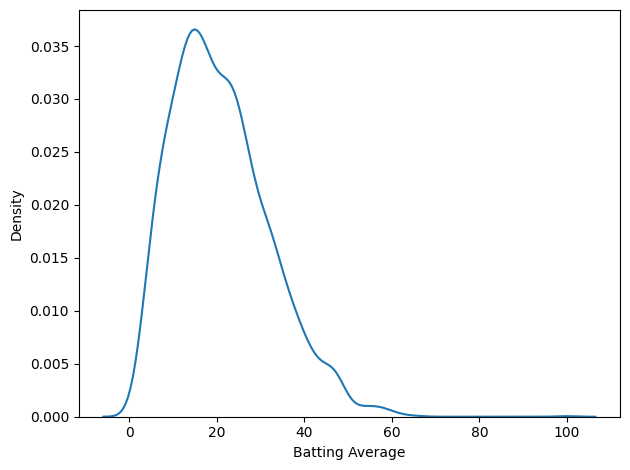

In [5]:
import seaborn as sns

sns.kdeplot(df['Batting Average'])
decorate()

That's not much of a bell curve. It's pretty clearly skewed to the right, even if we leave Bradman out of it.
But let's fit a Gaussian to it anyway.

## The Gaussian Model

There are a lot of ways to fit a model to data.
The one I like for applications like this is percentile matching -- that is, finding a model that minimizes the average vertical distance between the empirical CDF of the data and the CDF of the model.
That's what `fit_normal` does.

In [6]:
avg_series = df["Batting Average"].dropna()
gaussian_model = fit_normal(avg_series)

Here's what that looks like, plotting the tail distribution, which is the complement of the CDF.
The shaded area shows the differences between the data and the model.

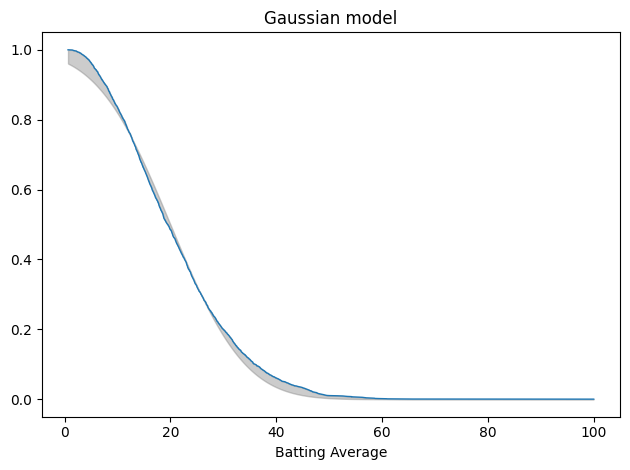

In [7]:
tail_data = TailDist.from_seq(avg_series)
plot_fit_with_area(tail_data, gaussian_model, kind="tail")
decorate(xlabel="Batting Average", title='Gaussian model')

This is not a great fit. There are clear differences in the shapes of the tail distributions.

And here's the average error, which is related to the area between the curves.

In [8]:
mae_normal = average_error(avg_series, gaussian_model)
mae_normal

0.017745997600540485

When we plot the tail distributions on linear scales, it looks like the model might be good enough. The problem is that we can't see what's happening in the tail.
For that, it's useful to plot the tail distributions on a log-y scale.

In [9]:
n = len(avg_series)
qs = np.linspace(tail_data.qs.min(), tail_data.qs.max(), 200)
tail_model = TailDist(gaussian_model.sf(qs), index=qs)

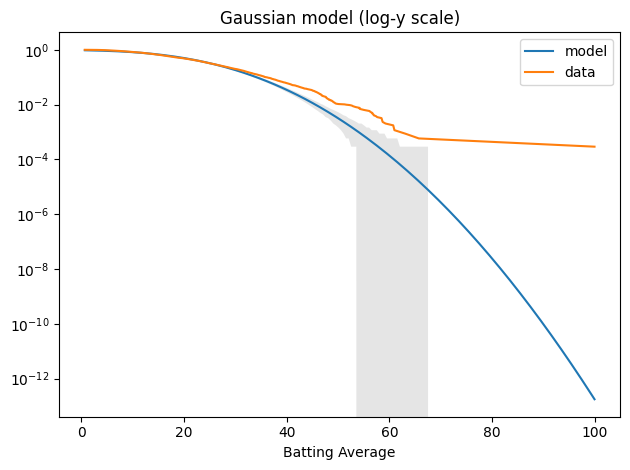

In [10]:
plot_model_bounds(gaussian_model, n=n, qs=qs, kind="tail", color="gray", alpha=0.2)
tail_model.plot(label="model")
tail_data.plot(label="data")
decorate(yscale="log", title='Gaussian model (log-y scale)')

The model fits the left side of the distribution well, but after that, it diverges badly.
Around 60, the difference between the model and the data is about an order of magnitude.

Nevertheless, we can use the Gaussian model to compute the probability of a batting average as high as Bradman's 99.94.

In [11]:
BRADMAN = 99.94


def probability_of_exceeding(model, x, n):
    p = model.cdf(x)
    one_in = 1 / (1 - p)
    in_sample = 1 / (1 - p ** n)
    return one_in, in_sample

In the fitted distribution, the probability of a single batter achieving Bradman's average is about one per 5.7 trillion.

In [12]:
one_in, in_sample = probability_of_exceeding(gaussian_model, BRADMAN, n)
one_in / 1e12

5.71160383940456

And even if we account for the sample size, the probability that one of 3438 batsman reaches that level is 1.7 per billion.
So, according to the Gaussian model, this outcome is basically impossible.

In [13]:
n, in_sample / 1e9

(3438, 1.6613158346144736)

But the Gaussian model doesn't fit the data well -- and there's no reason it should.
To see why not, let's think about the process that generates the distribution of batting averages.

As a simplifying assumption, suppose a batsman has the same probability of getting out at any time; in that case, the number of runs in an inning might follow a negative binomial (NB) distribution.
As we add up innings (or average over them), the total would eventually converge to a normal distribution, but most batsmans don't have enough innings to converge.
So for each batsman, the distribution of runs follows something between NB and normal.
And when we combine them, we get a mixture of those hybrids.
There's no obvious reason the results should fit a simple mathematical model.

But it turns out that they do.

## The Weibull Model

The Weibull distribution is not the first thing I thought of -- I tried a lognormal distribution first.
But a Weibull distribution fits the data really, really well.
The `fit_scipy_dist` is a more general version of `fit_normal` that works with any of the SciPy distributions.

In [14]:
weibull_model = fit_scipy_dist(avg_series, weibull_min)
weibull_model.args

(1.8667199063293203, 0.9939717502596944, 22.486446489455503)

Here's the result. Again, the gray area shows the difference between the data and the model.

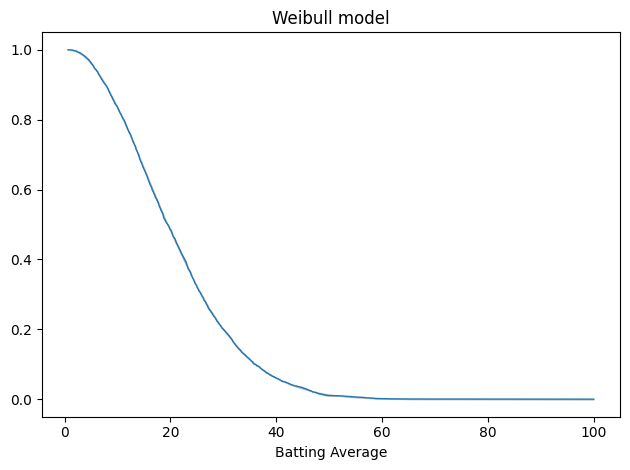

In [15]:
plot_fit_with_area(tail_data, weibull_model, kind="tail")
decorate(xlabel="Batting Average", title="Weibull model")

The gray area is not visible.
Here's the average error.

In [16]:
mae_weibull = average_error(avg_series, weibull_model)
mae_weibull

0.002555441381799216

The average error of the Gaussian model is about 7x bigger.

In [17]:
mae_normal / mae_weibull

6.944396270223196

Here's what the tail looks like on a log-y axis.

In [18]:
tail_model = TailDist(weibull_model.sf(qs), index=qs)

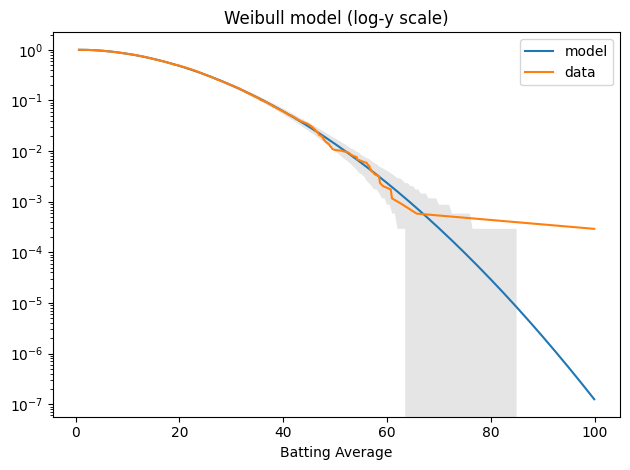

In [19]:
plot_model_bounds(weibull_model, n=n, qs=qs, kind="tail", color="gray", alpha=0.2)
tail_model.plot(label="model")
tail_data.plot(label="data")
decorate(yscale="log", title="Weibull model (log-y scale)")

The model fits the data well -- within the bounds of variability we expect for this sample size -- except for Bradman, who is still an outlier.

Again, we can compute the probability that any batter exceeds Bradman's level:

In [20]:
one_in, in_sample = probability_of_exceeding(weibull_model, BRADMAN, n)
one_in / 1e6

7.980438255436601

It's about 8 per million. And in a sample of 3438 batsmen, the chance that any one of them reaches that level is 2 per thousand.

In [21]:
in_sample / 1e3

2.3217442928624186

So Bradman is still an outlier among outliers, but not quite the statistical anomaly that he would be in a normal distribution.

Finally, let's think about why a Weibull distribution fits this dataset so well.
In the data-generating process I suggested earlier, if a batsman has the same probability of getting out at any time, the number of runs in an inning might follow a negative binomial (NB) distribution.
If we think of the run-generating process as continuous, the distribution of runs before an out would be exponential.
And if we relax the assumption that the hazard rate is constant, the distribution of runs per inning would be Weibull.

I think that's an intriguing first step, but at best it explains the distribution of runs per inning -- but not the distribution of batting averages across batsmen with, presumably, different hazard rates.

## Appendix: The Lognormal Model

Just for completeness, here's the lognormal model.

In [22]:
log_series = np.log10(avg_series)
log_model = fit_normal(log_series, x0=norm.fit(log_series))
tail_log_data = TailDist.from_seq(log_series)

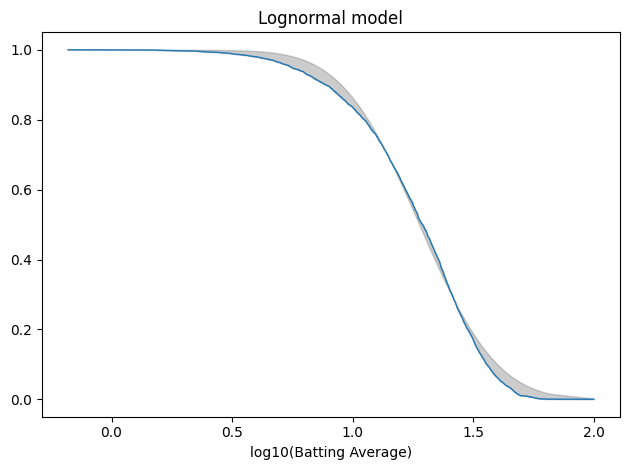

In [23]:
plot_fit_with_area(tail_log_data, log_model, kind="tail")
decorate(xlabel="log10(Batting Average)", title="Lognormal model")

The average error is slightly worse than the Gaussian model.

In [24]:
mae_lognormal = average_error(log_series, log_model)
mae_lognormal

0.01885918996726559

And it doesn't fit the tail well at all.

In [25]:
log_qs = np.log10(qs)
tail_model = TailDist(log_model.sf(log_qs), index=log_qs)

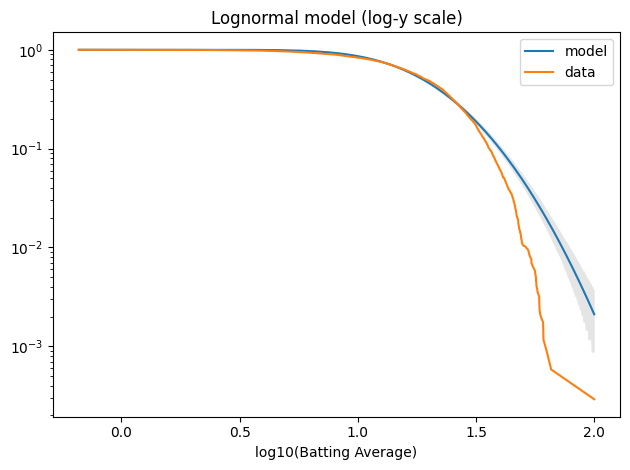

In [26]:
plot_model_bounds(log_model, n=n, qs=log_qs, kind="tail", color="gray", alpha=0.2)
tail_model.plot(label="model")
tail_log_data.plot(label="data")
decorate(xlabel="log10(Batting Average)", yscale="log", title="Lognormal model (log-y scale)")